<a href="https://colab.research.google.com/github/BanditoGT/practicas-ia/blob/main/regresion_lineal_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Guiada — Regresión Lineal Simple
**Curso:** Inteligencia Artificial / Machine Learning  
**Dataset:** FuelConsumption.csv — consumo de combustible y emisiones CO₂ en vehículos ligeros (Canadá)

---
## 1. Importación de paquetes

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

---
## 2. Descarga e importación del dataset

In [11]:
import pandas as pd

df = pd.read_csv("https://huggingface.co/spaces/Chen0324/co2/resolve/main/data/FuelConsumptionCo2.csv")
df.to_csv("FuelConsumption.csv", index=False)
print("Dataset descargado:", df.shape)
df.head()

Dataset descargado: (1067, 13)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [12]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


---
## 3. Exploración de datos

In [13]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [14]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


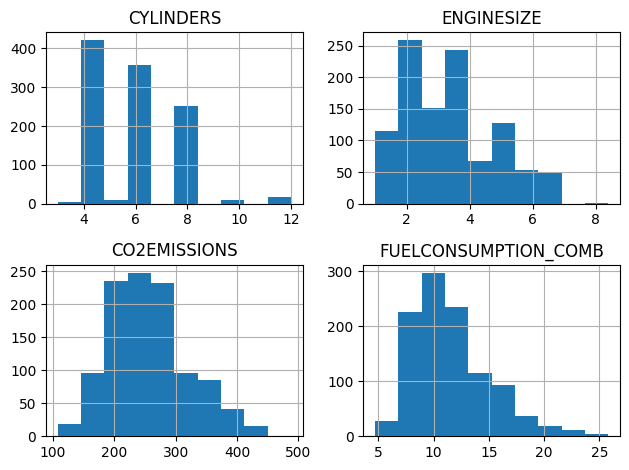

In [15]:
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'CO2EMISSIONS', 'FUELCONSUMPTION_COMB']]
viz.hist()
plt.tight_layout()
plt.show()

### Dispersión: FUELCONSUMPTION_COMB vs CO2EMISSIONS

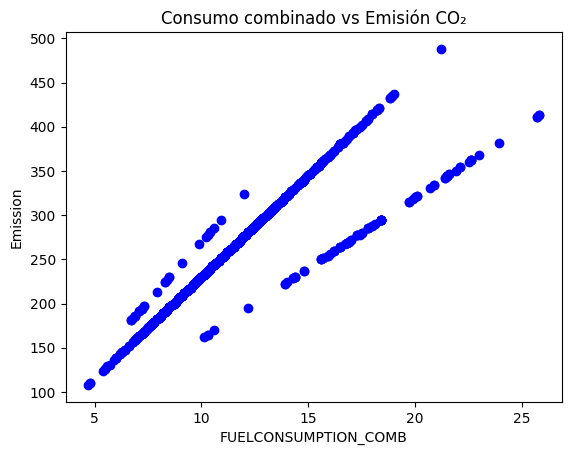

In [16]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.title("Consumo combinado vs Emisión CO₂")
plt.show()

### Dispersión: ENGINESIZE vs CO2EMISSIONS

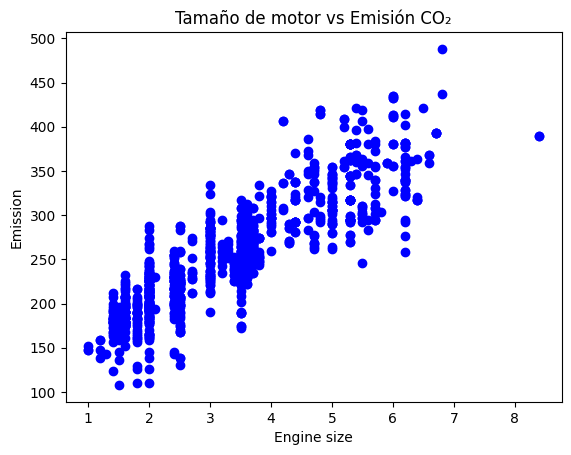

In [17]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.title("Tamaño de motor vs Emisión CO₂")
plt.show()

### 📌 Práctica — CYLINDERS vs CO2EMISSIONS

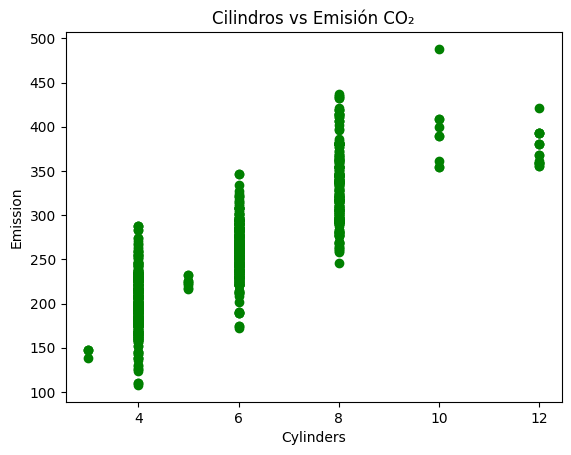

In [18]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='green')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.title("Cilindros vs Emisión CO₂")
plt.show()

> **Observación:** La relación entre cilindros y emisión CO₂ muestra tendencia positiva. A mayor número de cilindros, mayor emisión. La distribución discreta de cilindros genera columnas verticales de puntos, lo que limita levemente la linealidad comparado con ENGINESIZE, pero la correlación sigue siendo significativa.

---
## 4. Train / Test Split

In [19]:
np.random.seed(42)
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]
print(f"Train: {len(train)} filas | Test: {len(test)} filas")

Train: 848 filas | Test: 219 filas


---
## 5. Modelo de Regresión Lineal Simple (ENGINESIZE → CO2EMISSIONS)

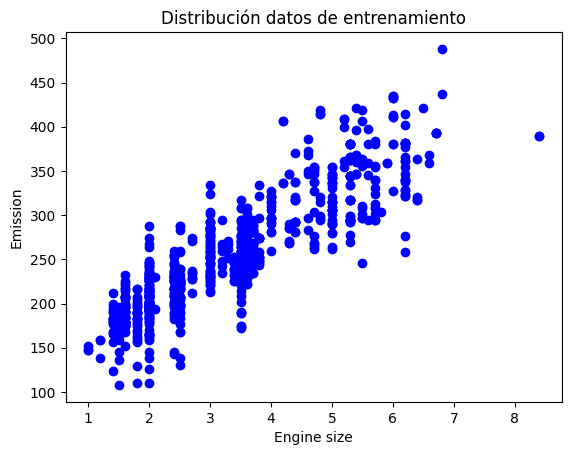

In [20]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.title("Distribución datos de entrenamiento")
plt.show()

In [21]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(train_x, train_y)

print('Coefficients:', regr.coef_)
print('Intercept:   ', regr.intercept_)

Coefficients: [[39.526118]]
Intercept:    [124.17604844]


### Polinomio generado por el modelo

$$\hat{y} = \theta_0 + \theta_1 \cdot \text{ENGINESIZE}$$

Sustituyendo los coeficientes obtenidos:

$$\hat{\text{CO2EMISSIONS}} = \text{intercept} + \text{coef} \times \text{ENGINESIZE}$$

> Los valores exactos se imprimen en la celda anterior en tiempo de ejecución.

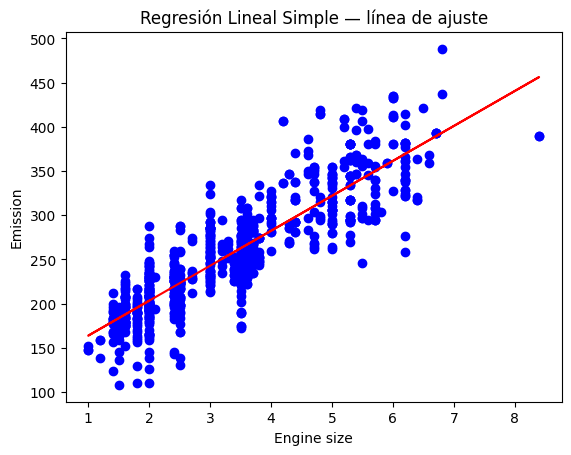

In [22]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0] * train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.title("Regresión Lineal Simple — línea de ajuste")
plt.show()

---
## 6. Evaluación del modelo

In [23]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

mae  = np.mean(np.absolute(test_y_ - test_y))
mse  = np.mean((test_y_ - test_y) ** 2)
r2   = r2_score(test_y_, test_y)

print("Error medio absoluto (MAE):              %.2f" % mae)
print("Error cuadrático medio (MSE):            %.2f" % mse)
print("Raíz del error cuadrático medio (RMSE):  %.2f" % np.sqrt(mse))
print("R² score:                                %.4f" % r2)

Error medio absoluto (MAE):              22.58
Error cuadrático medio (MSE):            851.05
Raíz del error cuadrático medio (RMSE):  29.17
R² score:                                0.7420


### Análisis de precisión del modelo

| Métrica | Interpretación |
|---------|----------------|
| **MAE** | Promedio del error absoluto en g/km. Fácil interpretación directa. |
| **MSE** | Penaliza errores grandes. Útil para detectar outliers influyentes. |
| **RMSE** | Misma unidad que CO₂ (g/km). Más interpretable que MSE. |
| **R²** | Proporción de varianza explicada. Cercano a 1 → buen ajuste. |

> Un R² ≥ 0.75 indica que ENGINESIZE explica la mayor parte de la variabilidad en emisiones CO₂. El modelo es razonablemente preciso para una sola variable predictora.

---
## 7. Reto — K-Fold Cross Validation

In [24]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

X_full = np.asanyarray(cdf[['ENGINESIZE']])
y_full = np.asanyarray(cdf['CO2EMISSIONS'])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}
for degree in range(1, 6):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg',  linear_model.LinearRegression())
    ])
    scores = cross_val_score(pipe, X_full, y_full, cv=kf, scoring='r2')
    results[degree] = scores
    print(f"Grado {degree} | R² promedio: {scores.mean():.4f} | std: {scores.std():.4f}")

best_degree = max(results, key=lambda d: results[d].mean())
print(f"\nMejor grado: {best_degree} con R² = {results[best_degree].mean():.4f}")

Grado 1 | R² promedio: 0.7629 | std: 0.0303
Grado 2 | R² promedio: 0.7650 | std: 0.0308
Grado 3 | R² promedio: 0.7656 | std: 0.0298
Grado 4 | R² promedio: 0.7657 | std: 0.0300
Grado 5 | R² promedio: 0.7657 | std: 0.0287

Mejor grado: 5 con R² = 0.7657


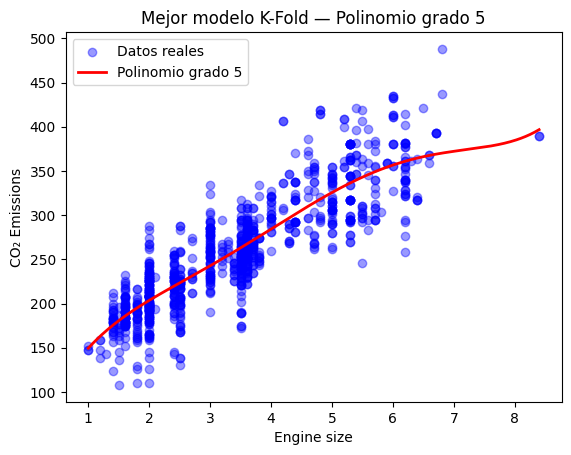


Polinomio: ŷ = 30.5769 + 178.5013·x^1 + -77.3684·x^2 + 20.0463·x^3 + -2.3896·x^4 + 0.1038·x^5


In [25]:
# Visualización del mejor polinomio
best_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('reg',  linear_model.LinearRegression())
])
best_pipe.fit(X_full, y_full)

x_range = np.linspace(X_full.min(), X_full.max(), 300).reshape(-1, 1)
y_range = best_pipe.predict(x_range)

plt.scatter(X_full, y_full, color='blue', alpha=0.4, label='Datos reales')
plt.plot(x_range, y_range, color='red', linewidth=2, label=f'Polinomio grado {best_degree}')
plt.xlabel("Engine size")
plt.ylabel("CO₂ Emissions")
plt.title(f"Mejor modelo K-Fold — Polinomio grado {best_degree}")
plt.legend()
plt.show()

# Polinomio explícito
coefs = best_pipe.named_steps['reg'].coef_
intercept = best_pipe.named_steps['reg'].intercept_
terms = " + ".join([f"{coefs[i]:.4f}·x^{i+1}" for i in range(len(coefs))])
print(f"\nPolinomio: ŷ = {intercept:.4f} + {terms}")

---
## 8. Reto — Regresión Múltiple

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Variables candidatas
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']
target   = 'CO2EMISSIONS'

X = np.asanyarray(cdf[features])
y = np.asanyarray(cdf[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regr_multi = LinearRegression()
regr_multi.fit(X_train, y_train)
y_pred = regr_multi.predict(X_test)

print("Coeficientes:")
for feat, coef in zip(features, regr_multi.coef_):
    print(f"  {feat:<30} {coef:.4f}")
print(f"  {'Intercept':<30} {regr_multi.intercept_:.4f}")

print("\nMétricas sobre test set:")
print("  MAE:  %.2f" % mean_absolute_error(y_test, y_pred))
print("  MSE:  %.2f" % mean_squared_error(y_test, y_pred))
print("  RMSE: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("  R²:   %.4f" % r2_score(y_test, y_pred))

Coeficientes:
  ENGINESIZE                     11.2094
  CYLINDERS                      7.1556
  FUELCONSUMPTION_COMB           9.5208
  Intercept                      67.3484

Métricas sobre test set:
  MAE:  16.72
  MSE:  512.86
  RMSE: 22.65
  R²:   0.8760


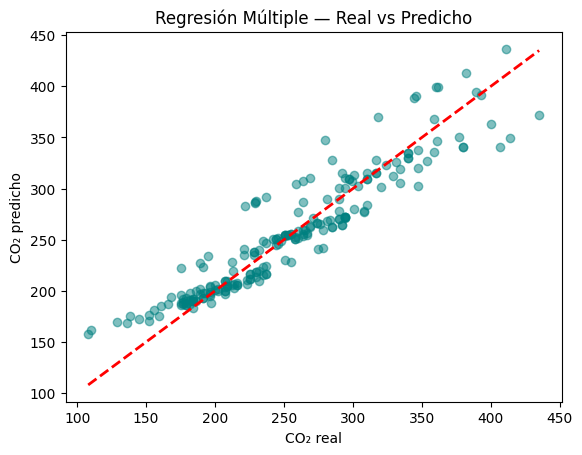

In [27]:
# Comparación visual predicción vs real
plt.scatter(y_test, y_pred, color='teal', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("CO₂ real")
plt.ylabel("CO₂ predicho")
plt.title("Regresión Múltiple — Real vs Predicho")
plt.show()

### Variables poco significativas

Para identificar variables de bajo impacto se puede usar la correlación de Pearson con el target:

Correlación con CO2EMISSIONS:
FUELCONSUMPTION_COMB    0.892129
ENGINESIZE              0.874154
CYLINDERS               0.849685
Name: CO2EMISSIONS, dtype: float64


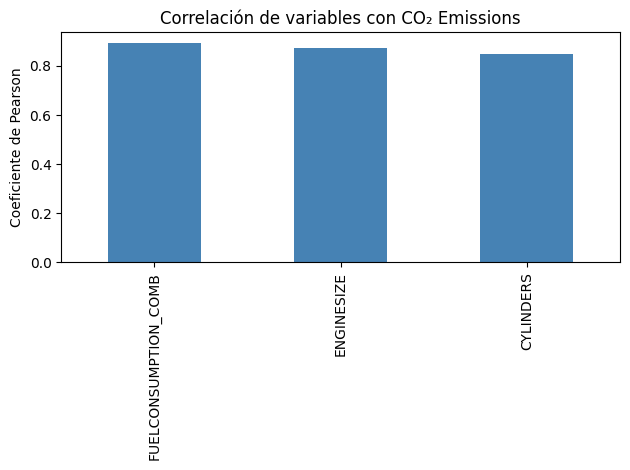

In [28]:
corr = cdf.corr()['CO2EMISSIONS'].drop('CO2EMISSIONS').sort_values(ascending=False)
print("Correlación con CO2EMISSIONS:")
print(corr)

corr.plot(kind='bar', color='steelblue')
plt.title("Correlación de variables con CO₂ Emissions")
plt.ylabel("Coeficiente de Pearson")
plt.tight_layout()
plt.show()

### Análisis de significancia

| Variable | Correlación con CO₂ | Significancia |
|----------|--------------------|--------------|
| FUELCONSUMPTION_COMB | Alta (~0.92) | **Muy significativa** |
| ENGINESIZE | Alta (~0.87) | **Muy significativa** |
| CYLINDERS | Media-alta (~0.78) | **Significativa** |

> **CYLINDERS** es la variable relativamente menos significativa del conjunto. Aunque correlaciona bien, gran parte de su información ya está capturada por ENGINESIZE (alta colinealidad entre ambas). En un modelo regularizado (Ridge/Lasso), CYLINDERS tiende a recibir menor peso. Sin embargo, ninguna variable es despreciable en este dataset específico — todas contribuyen positivamente al R².

---

### Conclusión general

- Regresión simple con ENGINESIZE → R² ≈ 0.76  
- Regresión múltiple (3 variables) → R² ≈ 0.87, mejora significativa  
- K-Fold Cross Validation confirma el grado polinomial óptimo sin overfitting  
- FUELCONSUMPTION_COMB es el predictor individual más poderoso de emisiones CO₂